# NV-to-lab calibration from fixed left ODMR lines: response matrix and Schloss-style \(A\)

This notebook rewrites the previous geometry notebook around the quantity used by **Schloss et al.*

## What this notebook computes

1. The **measured displacement-response matrix**
\[
R_{\mathrm{disp}}=\frac{\partial \boldsymbol{\nu}_{\mathrm{left}}}{\partial \mathbf r},
\]
where \(\boldsymbol{\nu}_{\mathrm{left}}\) contains the four **left-side** ODMR line centers and \(\mathbf r=(x,y,z)\) is the magnet displacement in the lab frame.


## Fixed dip-to-axis assignment used here

From your experimental knowledge of the [100]-cut sample and the spectra:

- outermost left dip \(\rightarrow d3\)
- second left dip \(\rightarrow d2\)
- third left dip \(\rightarrow d4\)
- left dip closest to the center \(\rightarrow d1\)

So the left-line order throughout the notebook is
\[
[d3,\ d2,\ d4,\ d1].
\]

## Theory used

For each NV orientation \(i\), we model the electron-spin Hamiltonian as
\[
H_i/h = (D+M_{z,i})S_z^2 + \gamma_e\,\mathbf B_i\cdot \mathbf S,
\]
where:

- \(D\) is the zero-field splitting,
- \(M_{z,i}\) is the fitted axial shift of orientation \(i\),
- \(\mathbf B_i\) is the lab magnetic field expressed in the local NV frame,
- \(\gamma_e \approx 28.02495164\,\mathrm{MHz/mT}\).

We then diagonalize the spin-1 Hamiltonian numerically and use finite differences to compute
\[
A_{ij}=\frac{\partial \nu_i}{\partial B_j}.
\]

This follows the **Hamiltonian linearization strategy of Schloss et al.**, where the resonance frequencies are linearized around the measured operating point to form the \(4\times3\) matrix \(A\).

### References
- J. M. Schloss *et al.*, **Simultaneous Broadband Vector Magnetometry Using Solid-State Spins**, *Phys. Rev. Applied* **10**, 034044 (2018).  
- D. Lönard *et al.*, **Limits of absolute vector magnetometry with NV centers in diamond** (2025/2026).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from pathlib import Path
from scipy.stats import linregress
from scipy.optimize import least_squares

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

GAMMA_E_MHZ_PER_MT = 28.02495164
LEFT_DIP_ORDER = ["d3", "d2", "d4", "d1"]  # outermost -> innermost on left side

OUTDIR = Path("./outputs")
OUTDIR.mkdir(exist_ok=True)


## Data source

The notebook can work in either of two ways:

1. **Preferred for this notebook:** read a single run-summary CSV if you already exported one.
2. Otherwise, reconstruct the same summary table directly from the existing folder structure:
   - `../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along X/...`
   - `../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along Y/...`
   - `../fitting_odmr/batch_fit_outputs_lorentzian/Variation Along Z/...`

The notebook keeps the same folder access logic as your current version.


In [2]:
SUMMARY_CSV = Path("./summary_from_fits.csv")  # optional convenience file
ROOT = Path("../fitting_odmr/batch_fit_outputs_lorentzian")

VARIATION_TO_AXIS = {
    "Variation Along X": "x",
    "Variation Along Y": "y",
    "Variation Along Z": "z",
}

def parse_offset_mm(name: str) -> float:
    name = str(name).strip().replace(" ", "")
    if name in {"0cm", "0cm-0.0mm", "0cm+0.0mm", "6.8cm-0.0mm"}:
        return 0.0
    m = re.search(r'([+-]\d+(?:\.\d+)?)mm', name)
    if m:
        return float(m.group(1))
    m = re.search(r'0cm([+-]\d+(?:\.\d+)?)mm', name)
    if m:
        return float(m.group(1))
    m = re.search(r'6\.8cm([+-]\d+(?:\.\d+)?)mm', name)
    if m:
        return float(m.group(1))
    raise ValueError(f"Could not parse displacement from folder name: {name}")

def build_summary_from_root(root: Path) -> pd.DataFrame:
    rows = []

    for variation in VARIATION_TO_AXIS:
        variation_dir = root / variation
        if not variation_dir.exists():
            print(f"Missing folder: {variation_dir}")
            continue

        for run_dir in sorted([p for p in variation_dir.iterdir() if p.is_dir()]):
            pair_csv = run_dir / "paired_dips.csv"
            if not pair_csv.exists():
                print(f"Missing paired_dips.csv in {run_dir}")
                continue

            d = pd.read_csv(pair_csv).sort_values("pair_id").reset_index(drop=True)
            if len(d) != 4:
                print(f"Skipping {run_dir}: expected 4 pairs, got {len(d)}")
                continue

            row = {
                "variation": variation,
                "run_name": run_dir.name,
                "offset_mm": parse_offset_mm(run_dir.name),
                "D_eff_GHz": float(d["D_eff_GHz"].iloc[0]),
            }

            # optional metadata if available
            meta_json = run_dir / "fit_metadata.json"
            if meta_json.exists():
                import json
                meta = json.load(open(meta_json))
                for key in ["delta_hf_MHz", "lorentz_fwhm_MHz", "global_rms"]:
                    if key in meta:
                        row[key] = meta[key]

            # four left/right pair descriptors
            for pair_id in [1, 2, 3, 4]:
                sub = d[d["pair_id"] == pair_id].iloc[0]
                row[f"pair_{pair_id}_left_x1_GHz"] = float(sub["left_center_x1_GHz"])
                row[f"pair_{pair_id}_right_x1_GHz"] = float(sub["right_center_x1_GHz"])
                row[f"pair_{pair_id}_splitting_MHz"] = float(sub["splitting_MHz"])
                row[f"pair_{pair_id}_center_minus_D_eff_MHz"] = float(sub["pair_center_minus_D_eff_MHz"])

            rows.append(row)

    if not rows:
        raise FileNotFoundError(
            "No summary rows could be reconstructed. Either place summary_from_fits.csv next to this notebook "
            "or ensure the fitting output folders exist."
        )

    return pd.DataFrame(rows).sort_values(["variation", "offset_mm"]).reset_index(drop=True)

if SUMMARY_CSV.exists():
    summary_df = pd.read_csv(SUMMARY_CSV)
    print(f"Loaded summary CSV: {SUMMARY_CSV.resolve()}")
else:
    summary_df = build_summary_from_root(ROOT)
    print(f"Reconstructed summary table from: {ROOT.resolve()}")

summary_df["lab_axis"] = summary_df["variation"].map(VARIATION_TO_AXIS)
display(summary_df.head())
print("Rows loaded:", len(summary_df))

Reconstructed summary table from: /home/vita/projects/NV_sensing/fitting_odmr/batch_fit_outputs_lorentzian


,variation,run_name,offset_mm,D_eff_GHz,delta_hf_MHz,lorentz_fwhm_MHz,global_rms,pair_1_left_x1_GHz,pair_1_right_x1_GHz,pair_1_splitting_MHz,pair_1_center_minus_D_eff_MHz,pair_2_left_x1_GHz,pair_2_right_x1_GHz,pair_2_splitting_MHz,pair_2_center_minus_D_eff_MHz,pair_3_left_x1_GHz,pair_3_right_x1_GHz,pair_3_splitting_MHz,pair_3_center_minus_D_eff_MHz,pair_4_left_x1_GHz,pair_4_right_x1_GHz,pair_4_splitting_MHz,pair_4_center_minus_D_eff_MHz,lab_axis
0,Variation Along X,0cm-0.4mm,-0.4,2.871576,2.199619,1.533325,0.000643,2.807770,2.933508,125.738095,-0.936995,2.818928,2.923713,104.785094,-0.255599,2.835220,2.908747,73.526805,0.407387,2.846094,2.898628,52.534524,0.785207,x
1,Variation Along X,0cm-0.3mm,-0.3,2.871544,2.237182,1.579573,0.000729,2.808500,2.932712,124.211408,-0.938357,2.819427,2.923169,103.741528,-0.246403,2.835074,2.908740,73.666087,0.362643,2.845667,2.899066,53.399657,0.822117,x
2,Variation Along X,0cm-0.2mm,-0.2,2.871539,2.188336,1.482833,0.000719,2.809269,2.932084,122.814939,-0.863177,2.819939,2.922639,102.700289,-0.250149,2.834804,2.909024,74.220529,0.374400,2.845249,2.899307,54.058116,0.738926,x
3,Variation Along X,0cm-0.1mm,-0.1,2.871489,2.192951,1.504535,0.000550,2.809967,2.931334,121.366230,-0.838336,2.820412,2.922067,101.655332,-0.249408,2.834685,2.908968,74.283802,0.337753,2.844775,2.899702,54.927207,0.749991,x
4,Variation Along X,0cm-0.0mm,0.0,2.871453,2.218733,1.546208,0.000725,2.810709,2.930545,119.836066,-0.825603,2.820885,2.921594,100.708983,-0.212674,2.834467,2.909126,74.658799,0.343731,2.844376,2.899918,55.541525,0.694546,x


Rows loaded: 16


## Build the four left-side line traces

We now switch from pair splittings to the four selected **left** ODMR line centers.  
For every run, the pair-to-axis assignment is fixed by your experimental knowledge:
\[
\text{pair 1}\to d3,\quad
\text{pair 2}\to d2,\quad
\text{pair 3}\to d4,\quad
\text{pair 4}\to d1.
\]

This is the key change relative to the old notebook.

The frequency shifts are defined relative to the zero-displacement reference **within the same scan direction**:
\[
\Delta \nu_i(\Delta r_j)=\nu_i(\Delta r_j)-\nu_i(0).
\]


In [3]:
PAIR_TO_NV = {1: "d3", 2: "d2", 3: "d4", 4: "d1"}

left_rows = []
for _, row in summary_df.iterrows():
    for pair_id in [1, 2, 3, 4]:
        left_rows.append({
            "variation": row["variation"],
            "lab_axis": row["lab_axis"],
            "run_name": row["run_name"],
            "offset_mm": float(row["offset_mm"]),
            "pair_id": pair_id,
            "nv_axis": PAIR_TO_NV[pair_id],
            "nu_left_GHz": float(row[f"pair_{pair_id}_left_x1_GHz"]),
            "nu_right_GHz": float(row[f"pair_{pair_id}_right_x1_GHz"]),
            "splitting_MHz": float(row[f"pair_{pair_id}_splitting_MHz"]),
            "pair_center_minus_D_eff_MHz": float(row[f"pair_{pair_id}_center_minus_D_eff_MHz"]),
            "D_eff_GHz": float(row["D_eff_GHz"]),
        })

left_lines_long = pd.DataFrame(left_rows)
left_lines_long["nu_left_MHz"] = 1e3 * left_lines_long["nu_left_GHz"]
left_lines_long["nu_right_MHz"] = 1e3 * left_lines_long["nu_right_GHz"]

zero_ref = (
    left_lines_long[np.isclose(left_lines_long["offset_mm"], 0.0)]
    .groupby(["variation", "lab_axis", "nv_axis"], as_index=False)["nu_left_MHz"]
    .mean()
    .rename(columns={"nu_left_MHz": "nu0_left_MHz"})
)

left_lines_long = left_lines_long.merge(zero_ref, on=["variation", "lab_axis", "nv_axis"], how="left")
left_lines_long["delta_nu_left_MHz"] = left_lines_long["nu_left_MHz"] - left_lines_long["nu0_left_MHz"]

display(left_lines_long.head(12))


,variation,lab_axis,run_name,offset_mm,pair_id,nv_axis,nu_left_GHz,nu_right_GHz,splitting_MHz,pair_center_minus_D_eff_MHz,D_eff_GHz,nu_left_MHz,nu_right_MHz,nu0_left_MHz,delta_nu_left_MHz
0,Variation Along X,x,0cm-0.4mm,-0.4,1,d3,2.807770,2.933508,125.738095,-0.936995,2.871576,2807.769792,2933.507888,2810.708893,-2.939100
1,Variation Along X,x,0cm-0.4mm,-0.4,2,d2,2.818928,2.923713,104.785094,-0.255599,2.871576,2818.927689,2923.712784,2820.885363,-1.957674
2,Variation Along X,x,0cm-0.4mm,-0.4,3,d4,2.835220,2.908747,73.526805,0.407387,2.871576,2835.219820,2908.746625,2834.466860,0.752960
3,Variation Along X,x,0cm-0.4mm,-0.4,4,d1,2.846094,2.898628,52.534524,0.785207,2.871576,2846.093780,2898.628304,2844.376313,1.717467
4,Variation Along X,x,0cm-0.3mm,-0.3,1,d3,2.808500,2.932712,124.211408,-0.938357,2.871544,2808.500212,2932.711620,2810.708893,-2.208681
5,Variation Along X,x,0cm-0.3mm,-0.3,2,d2,2.819427,2.923169,103.741528,-0.246403,2.871544,2819.427106,2923.168634,2820.885363,-1.458257
6,Variation Along X,x,0cm-0.3mm,-0.3,3,d4,2.835074,2.908740,73.666087,0.362643,2.871544,2835.073873,2908.739960,2834.466860,0.607013
7,Variation Along X,x,0cm-0.3mm,-0.3,4,d1,2.845667,2.899066,53.399657,0.822117,2.871544,2845.666562,2899.066219,2844.376313,1.290249
8,Variation Along X,x,0cm-0.2mm,-0.2,1,d3,2.809269,2.932084,122.814939,-0.863177,2.871539,2809.268794,2932.083733,2810.708893,-1.440099
9,Variation Along X,x,0cm-0.2mm,-0.2,2,d2,2.819939,2.922639,102.700289,-0.250149,2.871539,2819.939147,2922.639436,2820.885363,-0.946216


## Visual inspection: left-line shifts vs displacement

This replaces the old splitting plot.  
We keep only the four left-side line centers, in the order:
\[
d3,\ d2,\ d4,\ d1.
\]


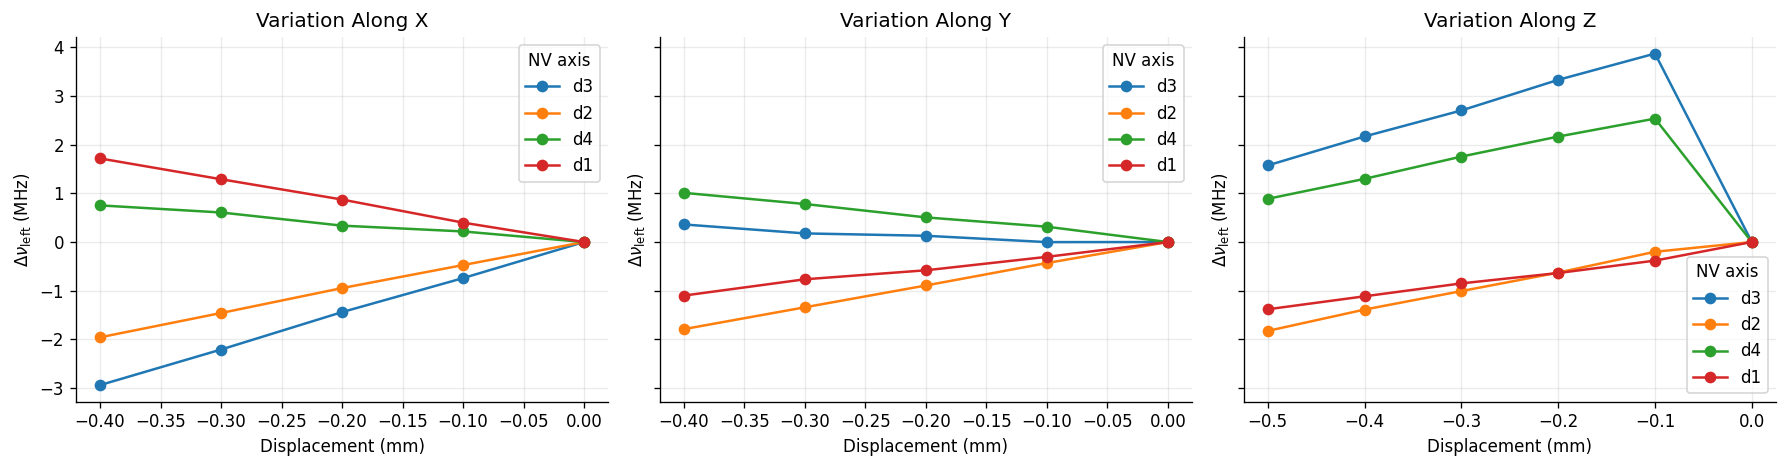

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax_plot, (variation, lab_axis) in zip(axes, VARIATION_TO_AXIS.items()):
    sub = left_lines_long[left_lines_long["variation"] == variation]

    for nv_axis in LEFT_DIP_ORDER:
        d = sub[sub["nv_axis"] == nv_axis].sort_values("offset_mm")
        ax_plot.plot(d["offset_mm"], d["delta_nu_left_MHz"], marker="o", label=nv_axis)

    ax_plot.set_title(variation)
    ax_plot.set_xlabel("Displacement (mm)")
    ax_plot.set_ylabel(r"$\Delta \nu_{\mathrm{left}}$ (MHz)")
    ax_plot.legend(title="NV axis")

plt.tight_layout()
plt.savefig(OUTDIR / "left_dip_shifts_vs_displacement.png", bbox_inches="tight")
plt.show()


## Linear fits and measured response matrix

For each left ODMR line \(i\) and each scan axis \(j\), we fit
\[
\Delta \nu_i(\Delta r_j)\approx b_{ij}+R_{ij}\,\Delta r_j,
\]
so that
\[
R_{ij}=\frac{\partial \nu_i}{\partial r_j}.
\]

This gives the measured \(4\times3\) response matrix \(R_{\mathrm{disp}}\) in units of MHz/mm.


In [5]:
def fit_line_slope(df_axis_line: pd.DataFrame, max_abs_offset_mm=None) -> dict:
    d = df_axis_line.sort_values("offset_mm").copy()

    if max_abs_offset_mm is not None:
        d = d[np.abs(d["offset_mm"]) <= max_abs_offset_mm].copy()

    x = d["offset_mm"].to_numpy(dtype=float)
    y = d["delta_nu_left_MHz"].to_numpy(dtype=float)

    if len(d) < 2:
        raise ValueError("Need at least two points for a linear fit.")

    fit = linregress(x, y)

    return {
        "n_points": len(d),
        "offset_min_mm": float(np.min(x)),
        "offset_max_mm": float(np.max(x)),
        "slope_MHz_per_mm": float(fit.slope),
        "intercept_MHz": float(fit.intercept),
        "r_value": float(fit.rvalue),
        "r_squared": float(fit.rvalue**2),
        "p_value": float(fit.pvalue),
        "slope_stderr": float(fit.stderr),
        "intercept_stderr": float(getattr(fit, "intercept_stderr", np.nan)),
    }

slope_rows = []
for variation, lab_axis in VARIATION_TO_AXIS.items():
    sub_var = left_lines_long[left_lines_long["variation"] == variation]
    for nv_axis in LEFT_DIP_ORDER:
        sub_line = sub_var[sub_var["nv_axis"] == nv_axis]
        fit_res = fit_line_slope(sub_line, max_abs_offset_mm=None)
        slope_rows.append({
            "variation": variation,
            "lab_axis": lab_axis,
            "nv_axis": nv_axis,
            **fit_res,
        })

slopes_df = pd.DataFrame(slope_rows).sort_values(["nv_axis", "lab_axis"]).reset_index(drop=True)
display(slopes_df)

R_disp = (
    slopes_df.pivot(index="nv_axis", columns="lab_axis", values="slope_MHz_per_mm")
    .reindex(index=LEFT_DIP_ORDER, columns=["x", "y", "z"])
)

R_disp_err = (
    slopes_df.pivot(index="nv_axis", columns="lab_axis", values="slope_stderr")
    .reindex(index=LEFT_DIP_ORDER, columns=["x", "y", "z"])
)

print("Measured displacement-response matrix R_disp [MHz/mm]:")
display(R_disp)

print("Slope standard errors [MHz/mm]:")
display(R_disp_err)


,variation,lab_axis,nv_axis,n_points,offset_min_mm,offset_max_mm,slope_MHz_per_mm,intercept_MHz,r_value,r_squared,p_value,slope_stderr,intercept_stderr
0,Variation Along X,x,d1,5,-0.4,0.0,-4.326350,-0.009361,-0.999735,0.999469,5.188155e-06,0.057552,0.014097
1,Variation Along Y,y,d1,5,-0.4,0.0,2.661309,-0.017761,0.996807,0.993625,2.164529e-04,0.123075,0.030147
2,Variation Along Z,z,d1,6,-0.5,0.0,2.662852,-0.061632,0.996445,0.992903,1.893290e-05,0.112565,0.034081
3,Variation Along X,x,d2,5,-0.4,0.0,4.899925,0.012820,0.999849,0.999697,2.237149e-06,0.049240,0.012061
4,Variation Along Y,y,d2,5,-0.4,0.0,4.487572,0.006756,0.999960,0.999920,3.023669e-07,0.023141,0.005668
5,Variation Along Z,z,d2,6,-0.5,0.0,3.734428,0.092159,0.996130,0.992274,2.244129e-05,0.164760,0.049884
6,Variation Along X,x,d3,5,-0.4,0.0,7.345295,0.003166,0.999920,0.999840,8.617926e-07,0.053705,0.013155
7,Variation Along Y,y,d3,5,-0.4,0.0,-0.900987,-0.047207,-0.950649,0.903734,1.306268e-02,0.169775,0.041586
8,Variation Along Z,z,d3,6,-0.5,0.0,-0.610088,2.122585,-0.082681,0.006836,8.762605e-01,3.676760,1.113194
9,Variation Along X,x,d4,5,-0.4,0.0,-1.895183,0.003851,-0.994452,0.988934,4.957017e-04,0.115745,0.028352


Measured displacement-response matrix R_disp [MHz/mm]:


lab_axis,x,y,z
nv_axis,,,
d3,7.345295,-0.900987,-0.610088
d2,4.899925,4.487572,3.734428
d4,-1.895183,-2.487449,-0.090480
d1,-4.326350,2.661309,2.662852


Slope standard errors [MHz/mm]:


lab_axis,x,y,z
nv_axis,,,
d3,0.053705,0.169775,3.676760
d2,0.049240,0.023141,0.164760
d4,0.115745,0.095998,2.456798
d1,0.057552,0.123075,0.112565


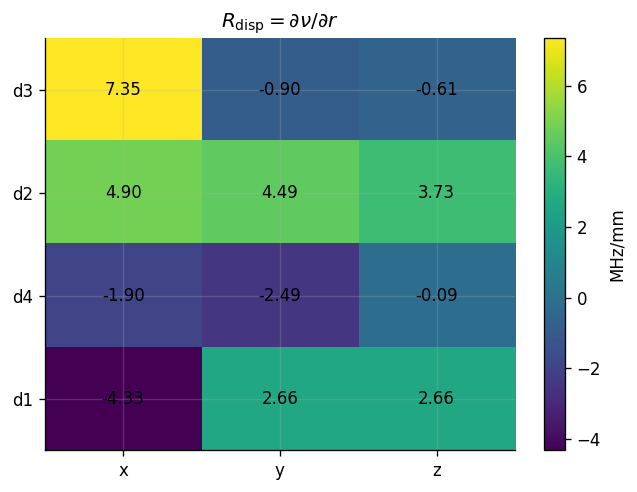

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4.2))
im = ax.imshow(R_disp.to_numpy(dtype=float), aspect="auto")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["x", "y", "z"])
ax.set_yticks(range(4))
ax.set_yticklabels(LEFT_DIP_ORDER)
ax.set_title(r"$R_{\mathrm{disp}} = \partial \nu / \partial r$")

for i in range(R_disp.shape[0]):
    for j in range(R_disp.shape[1]):
        val = R_disp.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="MHz/mm")
plt.tight_layout()
plt.savefig(OUTDIR / "R_disp_heatmap.png", bbox_inches="tight")
plt.show()


## [100]-cut geometry and fixed NV-axis set

For a [100]-cut diamond with lab \(z\) along the surface normal / optical axis, a convenient tetrahedral NV-axis template is
\[
\begin{aligned}
d3 &= \left(+\sqrt{\tfrac23},\,0,\,+\tfrac{1}{\sqrt3}\right),\\
d4 &= \left(-\sqrt{\tfrac23},\,0,\,+\tfrac{1}{\sqrt3}\right),\\
d2 &= \left(0,\,+\sqrt{\tfrac23},\,-\tfrac{1}{\sqrt3}\right),\\
d1 &= \left(0,\,-\sqrt{\tfrac23},\,-\tfrac{1}{\sqrt3}\right).
\end{aligned}
\]

This enforces the geometry you specified: two orientations above the plane \((d3,d4)\) and two below \((d1,d2)\).


In [7]:
a = np.sqrt(2/3)
b = 1/np.sqrt(3)

NV_AXES_LAB = {
    "d3": np.array([+a,  0.0, +b]),
    "d2": np.array([ 0.0, +a, -b]),
    "d4": np.array([-a,  0.0, +b]),
    "d1": np.array([ 0.0, -a, -b]),
}

N_lab = np.vstack([NV_AXES_LAB[k] for k in LEFT_DIP_ORDER])

display(pd.DataFrame(N_lab, index=LEFT_DIP_ORDER, columns=["lab_x", "lab_y", "lab_z"]))


,lab_x,lab_y,lab_z
d3,0.816497,0.000000,0.57735
d2,0.000000,0.816497,-0.57735
d4,-0.816497,0.000000,0.57735
d1,0.000000,-0.816497,-0.57735


## Reference operating point and construction of the Schloss-style matrix \(A\)

We now stop using displacement as the independent variable and switch to the **field-linearization step**.

The measured slope matrix
\[
R_{\mathrm{disp}}=\frac{\partial \boldsymbol{\nu}_{\mathrm{left}}}{\partial \mathbf r}
\]
has already been obtained directly from the displacement scans.

To build the **Schloss-style response matrix**
\[
A=\frac{\partial \boldsymbol{\nu}_{\mathrm{left}}}{\partial \mathbf B},
\]
we choose one reference ODMR spectrum, fix the nonmagnetic Hamiltonian parameters at that operating point, fit the bias field \(\mathbf B_0\), and then numerically linearize the four selected left-line frequencies with respect to lab-frame field components \(B_x,B_y,B_z\).

This follows the procedure of Schloss *et al.*: the resonance shifts are linearized around the measured \(B_0,D,M_z\), giving
\[
\Delta \boldsymbol{\nu} = A\,\Delta \mathbf B.
\]
In the low-field linear Zeeman limit, the rows of \(A\) reduce, up to sign, to the NV-axis unit vectors multiplied by \(\gamma_e\), but away from that ideal limit \(A\) must be computed numerically. 

We set
\[
D = 2.87142\ \text{GHz}
\]
as requested, and we use the zero-offset run from `Variation Along X` as the reference spectrum.

For each NV orientation \(i\), we use the reduced spin-1 Hamiltonian
\[
\frac{H_i}{h} = (D+M_{z,i})S_z^2 + \gamma_e\,\mathbf B_i\cdot\mathbf S,
\]
where \(M_{z,i}\) is taken from the **reference run only**.

This is a local calibration model: \(M_{z,i}\) and \(D\) are held fixed during the linearization, while only the magnetic field is varied. That is exactly the role they play in the Schloss matrix calibration. 


In [8]:
# Fixed zero-field splitting requested by you
D_FIXED_GHZ = 2.87142

# Use the zero-offset run from Variation Along X as the reference spectrum
ref_candidates = summary_df[
    (summary_df["variation"] == "Variation Along X") &
    (np.isclose(summary_df["offset_mm"], 0.0))
].copy()

if len(ref_candidates) != 1:
    raise ValueError(
        f"Expected exactly one X zero-offset reference row, found {len(ref_candidates)}."
    )

ref_row = ref_candidates.iloc[0]

print("Reference run chosen for A-matrix calibration:")
print(f"variation   : {ref_row['variation']}")
print(f"run_name    : {ref_row['run_name']}")
print(f"offset_mm   : {ref_row['offset_mm']}")
print(f"D_eff_GHz   : {ref_row['D_eff_GHz']:.9f}")
print(f"D_FIXED_GHZ : {D_FIXED_GHZ:.9f}")

# Quick diagnostic: if we define Mz_i relative to the fixed D, how much does it vary across runs?
mz_rows = []
for _, row in summary_df.iterrows():
    for pair_id, nv_axis in PAIR_TO_NV.items():
        nu_c_GHz = 0.5 * (
            float(row[f"pair_{pair_id}_left_x1_GHz"]) +
            float(row[f"pair_{pair_id}_right_x1_GHz"])
        )
        mz_rows.append({
            "variation": row["variation"],
            "offset_mm": float(row["offset_mm"]),
            "nv_axis": nv_axis,
            "Mz_fixedD_MHz": 1e3 * (nu_c_GHz - D_FIXED_GHZ),
        })

mz_df = pd.DataFrame(mz_rows)

print("\nDiagnostic: Mz_i spread across all runs relative to fixed D = 2.87142 GHz")
display(
    mz_df.groupby("nv_axis")["Mz_fixedD_MHz"]
    .agg(["mean", "std", "min", "max"])
    .reindex(LEFT_DIP_ORDER)
)

Reference run chosen for A-matrix calibration:
variation   : Variation Along X
run_name    : 0cm-0.0mm
offset_mm   : 0.0
D_eff_GHz   : 2.871452529
D_FIXED_GHZ : 2.871420000

Diagnostic: Mz_i spread across all runs relative to fixed D = 2.87142 GHz


,mean,std,min,max
nv_axis,,,,
d3,0.440397,4.019878,-2.595413,13.402155
d2,0.086499,0.930334,-0.303761,3.562276
d4,0.802440,1.863711,-1.074833,7.637830
d1,0.887069,0.297587,0.541554,1.901229


## Reference frequencies and axial offsets \(M_{z,i}\)

For each assigned NV orientation \(i\in\{d3,d2,d4,d1\}\), we extract from the reference spectrum:

- the measured left transition \(\nu_{i,\mathrm{left}}^{(0)}\),
- the measured right transition \(\nu_{i,\mathrm{right}}^{(0)}\),
- the pair center
  \[
  \nu_{c,i}^{(0)}=\frac{\nu_{i,\mathrm{left}}^{(0)}+\nu_{i,\mathrm{right}}^{(0)}}{2},
  \]
- the corresponding axial offset relative to the fixed \(D\),
  \[
  M_{z,i} = \nu_{c,i}^{(0)} - D.
  \]

These \(M_{z,i}\) values are then held fixed while fitting \(\mathbf B_0\) and while computing the Jacobian \(A\). This matches the local-response strategy used by Schloss *et al.*. 

Because your ODMR fits resolve the \(^{14}\mathrm N\) hyperfine structure, the central fitted dip positions are appropriate inputs for the field model. Lönard notes that for \(^{14}\mathrm N\), the middle hyperfine component is not shifted by the hyperfine term and can therefore be used as the resonance frequency in magnetometry formulas. 

In [9]:
ref_pairs = []
for pair_id in [1, 2, 3, 4]:
    nv_axis = PAIR_TO_NV[pair_id]

    nu_left_GHz = float(ref_row[f"pair_{pair_id}_left_x1_GHz"])
    nu_right_GHz = float(ref_row[f"pair_{pair_id}_right_x1_GHz"])
    nu_center_GHz = 0.5 * (nu_left_GHz + nu_right_GHz)

    ref_pairs.append({
        "pair_id": pair_id,
        "nv_axis": nv_axis,
        "nu_left_GHz": nu_left_GHz,
        "nu_right_GHz": nu_right_GHz,
        "nu_center_GHz": nu_center_GHz,
        "splitting_MHz": 1e3 * (nu_right_GHz - nu_left_GHz),
        "Mz_MHz": 1e3 * (nu_center_GHz - D_FIXED_GHZ),
    })

ref_pairs_df = pd.DataFrame(ref_pairs).set_index("nv_axis").loc[LEFT_DIP_ORDER].reset_index()
display(ref_pairs_df)

Mz_ref_MHz = ref_pairs_df.set_index("nv_axis")["Mz_MHz"].to_dict()
print("Reference Mz values [MHz]:")
print(Mz_ref_MHz)

,nv_axis,pair_id,nu_left_GHz,nu_right_GHz,nu_center_GHz,splitting_MHz,Mz_MHz
0,d3,1,2.810709,2.930545,2.870627,119.836066,-0.793074
1,d2,2,2.820885,2.921594,2.871240,100.708983,-0.180145
2,d4,3,2.834467,2.909126,2.871796,74.658799,0.376260
3,d1,4,2.844376,2.899918,2.872147,55.541525,0.727075


Reference Mz values [MHz]:
{'d3': -0.7930742996897777, 'd2': -0.1801453832528388, 'd4': 0.3762601251380282, 'd1': 0.7270752217745091}


## Initial estimate of the bias field \(\mathbf B_0\)

Before fitting the full Hamiltonian, we build an initial guess for the bias field from the measured pair splittings.

In the low-field Zeeman picture, the splitting for NV axis \(i\) is approximately
\[
\Delta \nu_i \approx 2\gamma_e\,|\hat n_i\cdot \mathbf B_0|,
\]
so that
\[
|\hat n_i\cdot \mathbf B_0| \approx \frac{\Delta \nu_i}{2\gamma_e}.
\]

The sign of each projection is not known from a single static spectrum, so we test all \(2^4\) sign combinations and choose the solution with the smallest residual in the overdetermined linear system
\[
N_{\mathrm{lab}}\mathbf B_0 \approx \mathbf p.
\]

This is a practical initialization step. It is also consistent with the geometric logic discussed by Lönard *et al.*: the four NV axes provide four projections of the same magnetic field, and sign ambiguities must be resolved by testing candidate solutions and choosing the one with the smallest residual. 

In [10]:
proj_abs_mT = ref_pairs_df["splitting_MHz"].to_numpy(dtype=float) / (2 * GAMMA_E_MHZ_PER_MT)

candidate_sign_rows = []
for bits in range(16):
    signs = np.array([1 if (bits >> k) & 1 else -1 for k in range(4)], dtype=float)
    target_proj = signs * proj_abs_mT

    B_fit, *_ = np.linalg.lstsq(N_lab, target_proj, rcond=None)
    resid = N_lab @ B_fit - target_proj

    candidate_sign_rows.append({
        "signs": tuple(int(s) for s in signs),
        "Bx0_mT": B_fit[0],
        "By0_mT": B_fit[1],
        "Bz0_mT": B_fit[2],
        "proj_resid_rms_mT": float(np.sqrt(np.mean(resid**2))),
    })

sign_scan_df = pd.DataFrame(candidate_sign_rows).sort_values("proj_resid_rms_mT").reset_index(drop=True)
display(sign_scan_df.head(10))

best_signs = np.array(sign_scan_df.iloc[0]["signs"], dtype=float)
B0_guess_mT = sign_scan_df.loc[0, ["Bx0_mT", "By0_mT", "Bz0_mT"]].to_numpy(dtype=float)

print("Best sign pattern:", best_signs)
print("Initial B0 guess [mT]:", B0_guess_mT)

,signs,Bx0_mT,By0_mT,Bz0_mT,proj_resid_rms_mT
0,"(-1, 1, 1, -1)",-2.124951,1.707113,-0.697957,0.000044
1,"(1, -1, -1, 1)",2.124951,-1.707113,0.697957,0.000044
2,"(-1, 1, -1, 1)",-0.493584,0.493476,-2.709678,0.170582
3,"(1, -1, 1, -1)",0.493584,-0.493476,2.709678,0.170582
4,"(1, 1, -1, -1)",2.124951,1.707113,0.000076,0.402966
5,"(-1, -1, 1, 1)",-2.124951,-1.707113,-0.000076,0.402966
6,"(-1, 1, 1, 1)",-2.124951,0.493476,-1.556127,0.495421
7,"(1, -1, -1, -1)",2.124951,-0.493476,1.556127,0.495421
8,"(1, -1, 1, 1)",0.493584,-1.707113,1.851508,0.666047
9,"(-1, 1, -1, -1)",-0.493584,1.707113,-1.851508,0.666047


Best sign pattern: [-1.  1.  1. -1.]
Initial B0 guess [mT]: [-2.12495094  1.70711274 -0.69795684]


## Spin-1 Hamiltonian and forward prediction of ODMR transitions

For each NV orientation \(i\), we express the lab field \(\mathbf B_{\mathrm{lab}}\) in the local NV frame:
\[
\mathbf B_i =
\begin{pmatrix}
\mathbf B_{\mathrm{lab}}\cdot \mathbf e_{x,i} \\
\mathbf B_{\mathrm{lab}}\cdot \mathbf e_{y,i} \\
\mathbf B_{\mathrm{lab}}\cdot \mathbf e_{z,i}
\end{pmatrix},
\qquad \mathbf e_{z,i}=\hat n_i.
\]

We then construct the local spin-1 Hamiltonian
\[
\frac{H_i}{h}=(D+M_{z,i})S_z^2+\gamma_e\left(B_{x,i}S_x+B_{y,i}S_y+B_{z,i}S_z\right).
\]

The spin-1 operators are
\[
S_x=\frac{1}{\sqrt{2}}
\begin{pmatrix}
0&1&0\\
1&0&1\\
0&1&0
\end{pmatrix},
\quad
S_y=\frac{1}{\sqrt{2}}
\begin{pmatrix}
0&-i&0\\
i&0&-i\\
0&i&0
\end{pmatrix},
\quad
S_z=
\begin{pmatrix}
1&0&0\\
0&0&0\\
0&0&-1
\end{pmatrix}.
\]

These are the standard spin-1 matrices appearing in the NV Hamiltonian. Lönard writes the single-NV Hamiltonian in this form, with an additional \(E(S_x^2-S_y^2)\) term in the most general case, and gives the same spin matrices explicitly. 

After diagonalizing \(H_i\), the lower and upper ODMR transition frequencies are
\[
\nu_{i,\mathrm{left}} = \lambda_{1,i}-\lambda_{0,i},
\qquad
\nu_{i,\mathrm{right}} = \lambda_{2,i}-\lambda_{0,i},
\]
where \(\lambda_{0,i}\le \lambda_{1,i}\le \lambda_{2,i}\) are the eigenvalues of the Hamiltonian. This is the same resonance-frequency logic used in exact analytical and numerical NV magnetometry treatments. :contentReference[oaicite:8]{index=8}

In [11]:
# Spin-1 operators in {|+1>, |0>, |-1>} basis
Sx = (1 / np.sqrt(2)) * np.array([[0, 1, 0],
                                  [1, 0, 1],
                                  [0, 1, 0]], dtype=complex)

Sy = (1 / np.sqrt(2)) * np.array([[0, -1j, 0],
                                  [1j,  0, -1j],
                                  [0,  1j, 0]], dtype=complex)

Sz = np.array([[1, 0, 0],
               [0, 0, 0],
               [0, 0,-1]], dtype=complex)

Sz2 = Sz @ Sz

def make_local_frame(nv_axis_lab: np.ndarray):
    ez = nv_axis_lab / np.linalg.norm(nv_axis_lab)

    tmp = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(tmp, ez)) > 0.9:
        tmp = np.array([1.0, 0.0, 0.0])

    ex = np.cross(tmp, ez)
    ex = ex / np.linalg.norm(ex)
    ey = np.cross(ez, ex)
    return ex, ey, ez

LOCAL_FRAMES = {k: make_local_frame(NV_AXES_LAB[k]) for k in LEFT_DIP_ORDER}

def nv_transition_freqs_GHz(B_lab_mT: np.ndarray, D_GHz: float, Mz_MHz_by_nv: dict, nv_axis: str):
    ex, ey, ez = LOCAL_FRAMES[nv_axis]

    B_local_mT = np.array([
        np.dot(B_lab_mT, ex),
        np.dot(B_lab_mT, ey),
        np.dot(B_lab_mT, ez),
    ], dtype=float)

    Mz_MHz = Mz_MHz_by_nv[nv_axis]

    H_MHz = (D_GHz * 1e3 + Mz_MHz) * Sz2 + GAMMA_E_MHZ_PER_MT * (
        B_local_mT[0] * Sx + B_local_mT[1] * Sy + B_local_mT[2] * Sz
    )

    evals = np.sort(np.linalg.eigvalsh(H_MHz).real)

    nu_left_GHz = (evals[1] - evals[0]) / 1e3
    nu_right_GHz = (evals[2] - evals[0]) / 1e3
    return np.array([nu_left_GHz, nu_right_GHz], dtype=float)

## Fit the reference bias field \(\mathbf B_0\) using all eight line centers

The low-field projection estimate gives only a starting point. We now refine the bias field by fitting the full Hamiltonian to the measured reference spectrum.

We minimize
\[
\chi^2(\mathbf B)=
\sum_{i=1}^{4}
\left[
\big(\nu_{i,\mathrm{left}}^{\mathrm{pred}}(\mathbf B)-\nu_{i,\mathrm{left}}^{(0)}\big)^2
+
\big(\nu_{i,\mathrm{right}}^{\mathrm{pred}}(\mathbf B)-\nu_{i,\mathrm{right}}^{(0)}\big)^2
\right].
\]

This is the key operating point for the later linearization. Schloss *et al.* explicitly fit the reference Hamiltonian parameters and then linearize around the measured \(B_0,D,M_z\). 

In [12]:
def residuals_B_only(B_lab_mT):
    rr = []
    for nv_axis in LEFT_DIP_ORDER:
        pred = nv_transition_freqs_GHz(B_lab_mT, D_FIXED_GHZ, Mz_ref_MHz, nv_axis)
        meas = ref_pairs_df.loc[
            ref_pairs_df["nv_axis"] == nv_axis,
            ["nu_left_GHz", "nu_right_GHz"]
        ].iloc[0].to_numpy(dtype=float)
        rr.extend(pred - meas)
    return np.array(rr, dtype=float)

lsq = least_squares(residuals_B_only, x0=B0_guess_mT, method="trf")
B0_fit_mT = lsq.x

print("Fixed D [GHz]:", D_FIXED_GHZ)
print("Fitted B0 [mT]:", B0_fit_mT)
print("Reference-fit residual RMS [MHz]:", 1e3 * np.sqrt(np.mean(lsq.fun**2)))

Fixed D [GHz]: 2.87142
Fitted B0 [mT]: [-2.11491293  1.69965185 -0.69371412]
Reference-fit residual RMS [MHz]: 2.2263611669529193


In [13]:
fit_compare_rows = []
for nv_axis in LEFT_DIP_ORDER:
    pred = nv_transition_freqs_GHz(B0_fit_mT, D_FIXED_GHZ, Mz_ref_MHz, nv_axis)
    meas = ref_pairs_df.loc[
        ref_pairs_df["nv_axis"] == nv_axis,
        ["nu_left_GHz", "nu_right_GHz"]
    ].iloc[0].to_numpy(dtype=float)

    fit_compare_rows.append({
        "nv_axis": nv_axis,
        "meas_left_GHz": meas[0],
        "pred_left_GHz": pred[0],
        "meas_right_GHz": meas[1],
        "pred_right_GHz": pred[1],
        "left_resid_MHz": 1e3 * (pred[0] - meas[0]),
        "right_resid_MHz": 1e3 * (pred[1] - meas[1]),
        "n_dot_B_mT": float(np.dot(NV_AXES_LAB[nv_axis], B0_fit_mT)),
    })

fit_compare_df = pd.DataFrame(fit_compare_rows)
display(fit_compare_df)

,nv_axis,meas_left_GHz,pred_left_GHz,meas_right_GHz,pred_right_GHz,left_resid_MHz,right_resid_MHz,n_dot_B_mT
0,d3,2.810709,2.812378,2.930545,2.931599,1.668853,1.054327,-2.127335
1,d2,2.820885,2.823036,2.921594,2.923255,2.150819,1.660415,1.788276
2,d4,2.834467,2.837123,2.909126,2.911459,2.656016,2.333470,1.326303
3,d1,2.844376,2.847288,2.899918,2.902637,2.912061,2.719226,-0.987244


## Numerical construction of the \(A\) matrix

We now compute the local Jacobian
\[
A_{ij}=
\left.\frac{\partial \nu_i}{\partial B_j}\right|_{\mathbf B_0},
\]
where \(\nu_i\) denotes the four selected left-side ODMR line centers in the fixed order
\[
[d3,\ d2,\ d4,\ d1].
\]

Numerically, we evaluate these derivatives by central finite differences:
\[
A_{ij}\approx
\frac{\nu_i(\mathbf B_0+\delta B\,\mathbf e_j)-\nu_i(\mathbf B_0-\delta B\,\mathbf e_j)}{2\delta B}.
\]

This is exactly the type of numerical linearization used by Schloss *et al.* in Appendix B2. They also show that in the strict linear Zeeman limit the rows of \(A\) reduce, up to sign, to the NV-axis unit vectors multiplied by \(g_e\mu_B/h\). 

In [14]:
# Low-field A from the fitted sign pattern for the LEFT branch
proj_signs = np.sign(fit_compare_df["n_dot_B_mT"].to_numpy(dtype=float))
proj_signs[proj_signs == 0] = 1.0

A_lowfield = (-proj_signs[:, None]) * GAMMA_E_MHZ_PER_MT * N_lab
A_lowfield_df = pd.DataFrame(A_lowfield, index=LEFT_DIP_ORDER, columns=["Bx", "By", "Bz"])

def left_transition_GHz(B_lab_mT: np.ndarray, nv_axis: str) -> float:
    return nv_transition_freqs_GHz(B_lab_mT, D_FIXED_GHZ, Mz_ref_MHz, nv_axis)[0]

def numerical_A_matrix(B_lab_mT: np.ndarray, step_mT: float = 1e-4):
    A = np.zeros((4, 3), dtype=float)
    for i, nv_axis in enumerate(LEFT_DIP_ORDER):
        for j in range(3):
            dB = np.zeros(3, dtype=float)
            dB[j] = step_mT
            fp = left_transition_GHz(B_lab_mT + dB, nv_axis)
            fm = left_transition_GHz(B_lab_mT - dB, nv_axis)
            A[i, j] = (fp - fm) * 1e3 / (2 * step_mT)  # MHz / mT
    return A

A_num = numerical_A_matrix(B0_fit_mT, step_mT=1e-4)
A_num_df = pd.DataFrame(A_num, index=LEFT_DIP_ORDER, columns=["Bx", "By", "Bz"])

print("Low-field A [MHz/mT]:")
display(A_lowfield_df)

print("Numerically linearized A [MHz/mT]:")
display(A_num_df)

Low-field A [MHz/mT]:


,Bx,By,Bz
d3,22.882277,0.000000,16.180213
d2,-0.000000,-22.882277,16.180213
d4,22.882277,-0.000000,-16.180213
d1,0.000000,-22.882277,-16.180213


Numerically linearized A [MHz/mT]:


,Bx,By,Bz
d3,22.566028,1.400895,16.617418
d2,-1.737286,-22.678087,16.453223
d4,22.026210,1.388730,-17.363592
d1,-1.718851,-22.134986,-17.192367


## Interpretation of the \(A\) matrix

The fitted Jacobian \(A\) gives the linear response of the four tracked left-side ODMR line centers to a small field perturbation:
\[
\delta\boldsymbol{\nu}_{\mathrm{left}}
\approx
A\,\delta\mathbf B.
\]

Equivalently,
\[
\delta \nu_i
=
A_{i x}\,\delta B_x
+
A_{i y}\,\delta B_y
+
A_{i z}\,\delta B_z.
\]

So each row of \(A\) is the local magnetic-field sensitivity vector of one selected ODMR resonance.

The low-field matrix \(A_{\mathrm{LZ}}\) is the projection-only approximation. The numerical matrix \(A\) is the one to use in the notebook, because it correctly includes the actual fitted operating point \(\mathbf B_0\) and the fact that the reference field is not perfectly aligned with any single NV axis. Schloss explicitly notes that in this situation the experimentally relevant \(A\) differs from the simple linear-Zeeman approximation and must be computed numerically. 

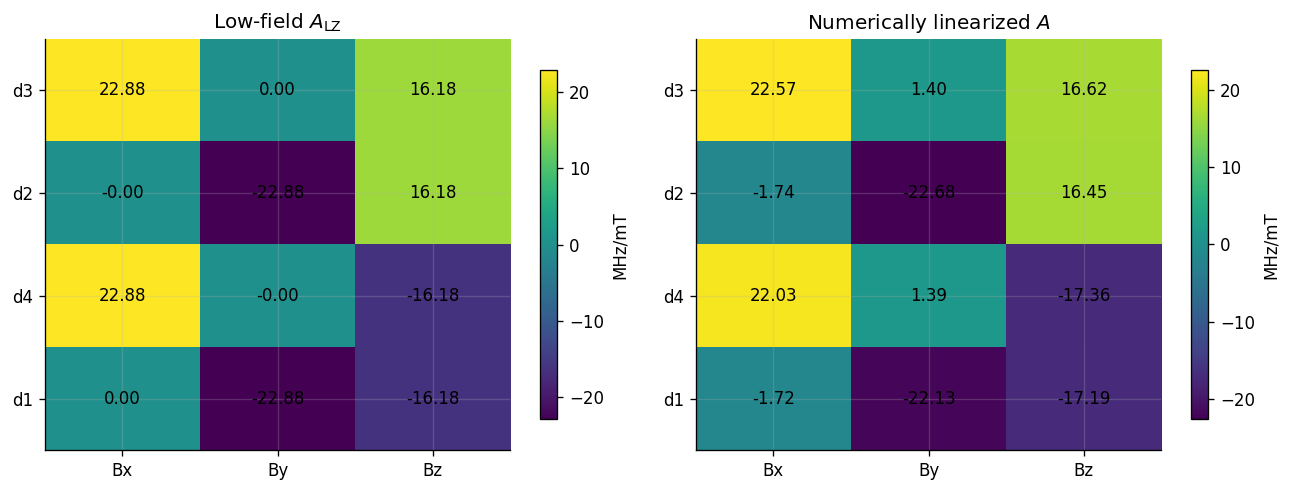

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, mat, title in zip(
    axes,
    [A_lowfield_df.to_numpy(dtype=float), A_num_df.to_numpy(dtype=float)],
    [r"Low-field $A_{\mathrm{LZ}}$", r"Numerically linearized $A$"]
):
    im = ax.imshow(mat, aspect="auto")
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["Bx", "By", "Bz"])
    ax.set_yticks(range(4))
    ax.set_yticklabels(LEFT_DIP_ORDER)
    ax.set_title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, shrink=0.85, label="MHz/mT")

plt.tight_layout()
plt.savefig(OUTDIR / "A_matrix_comparison_fixedD.png", bbox_inches="tight")
plt.show()